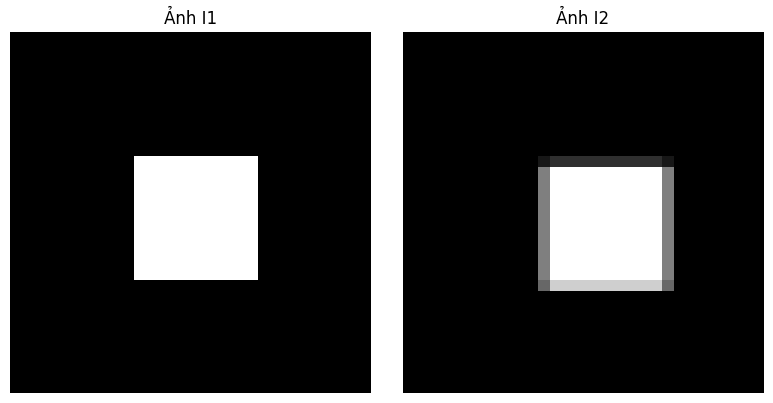

Kích thước ảnh I1: (32, 32)
Điểm tâm cần theo vết: (x_B, y_B) = (15.50, 15.50)
Kích thước cửa sổ W: 15x15
Số bước lặp: 30
---------------------------------------------------
Iter  1: c = (+0.2075, +0.1159), v = (+0.2075, +0.1159), det(M) = 501920101028066.437500
Iter  2: c = (+0.1813, +0.1000), v = (+0.3887, +0.2159), det(M) = 603690303985735.625000
Iter  3: c = (+0.1542, +0.0852), v = (+0.5429, +0.3012), det(M) = 745417606987616.875000
Iter  4: c = (+0.1348, +0.0729), v = (+0.6777, +0.3740), det(M) = 855127079031222.000000
Iter  5: c = (+0.1228, +0.0630), v = (+0.8005, +0.4371), det(M) = 847070250884989.875000
Iter  6: c = (+0.1079, +0.0548), v = (+0.9084, +0.4918), det(M) = 859626802348889.875000
Iter  7: c = (+0.0923, +0.0478), v = (+1.0008, +0.5397), det(M) = 889215274066357.500000
Iter  8: c = (+0.0778, +0.0429), v = (+1.0786, +0.5826), det(M) = 868021546878838.250000
Iter  9: c = (+0.0650, +0.0382), v = (+1.1436, +0.6209), det(M) = 848945045119163.625000
Iter 10: c = (+0.0542, +0

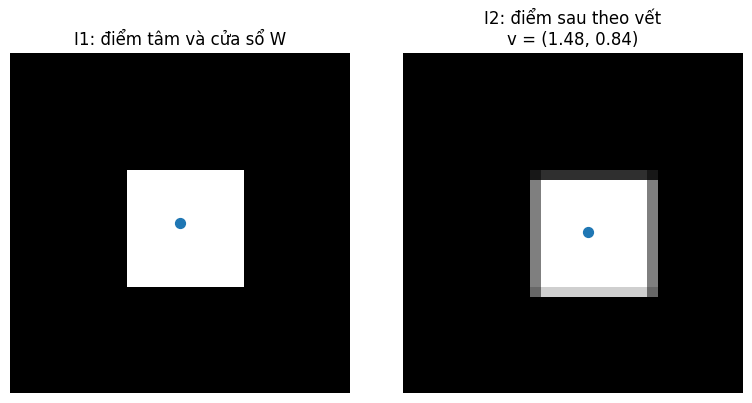

Kiểm tra hoàn tất: chương trình chạy đúng và kết quả hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: THEO VẾT ĐIỂM ẢNH BẰNG LUCAS-KANADE LẶP
# Chương/Mục liên quan: Chương 6 - Theo dõi đối tượng / Optical Flow
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán ước lượng chuyển động của một điểm ảnh giữa hai ảnh liên tiếp.
# - Giúp người học quan sát cách thuật toán Lucas-Kanade lặp cập nhật vector chuyển động.
# - Liên hệ phần code với mô hình tuyến tính cục bộ của optical flow.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của cửa sổ W quanh điểm cần theo vết.
# 2. Hiểu cách gradient ảnh được dùng để lập hệ phương trình tuyến tính.
# 3. Quan sát được sự hội tụ dần của vector chuyển động qua các bước lặp.

# Input:
# - Dữ liệu đầu vào: hai ảnh xám liên tiếp từ GitHub.
# - Kiểu dữ liệu: ảnh xám, lưu dưới dạng mảng NumPy float32.

# Output:
# - Ảnh I1 với điểm cần theo vết và cửa sổ W.
# - Ảnh I2 với điểm tương ứng sau khi ước lượng chuyển động.
# - Lịch sử cập nhật vector chuyển động qua từng bước lặp.
# - Kiểm tra kích thước ảnh, vector chuyển động và tọa độ điểm sau theo vết.

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

# Đọc ảnh grayscale từ URL
def read_gray_image_from_url(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    I = cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

    if I is None:
        raise ValueError(f"Không đọc được ảnh từ URL: {url}")

    return I.astype(np.float32)


# Khai báo URL ảnh
I1_url = "https://github.com/lthavnu/cv-book/raw/main/images/I1_for_tracking.png"
I2_url = "https://github.com/lthavnu/cv-book/raw/main/images/I2_for_tracking.png"

# Đọc hai ảnh liên tiếp
I1 = read_gray_image_from_url(I1_url)
I2 = read_gray_image_from_url(I2_url)

# Thiết lập điểm cần theo vết: tâm ảnh I1
H, W = I1.shape
x_B = (W - 1) / 2.0
y_B = (H - 1) / 2.0

# Thiết lập tham số Lucas-Kanade
win_size = 15
num_iters = 30

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(I1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Ảnh I1")
axes[0].axis("off")

axes[1].imshow(I2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Ảnh I2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Lấy giá trị ảnh tại tọa độ thực (x, y) bằng nội suy song tuyến tính
# x: theo cột, y: theo hàng
def bilinear_interpolate(I, x, y):
    H, W = I.shape

    # Kẹp tọa độ để không vượt biên
    x = np.clip(x, 0, W - 1.001)
    y = np.clip(y, 0, H - 1.001)

    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)

    x1 = x0 + 1
    y1 = y0 + 1

    x1 = np.clip(x1, 0, W - 1)
    y1 = np.clip(y1, 0, H - 1)

    Ia = I[y0, x0]
    Ib = I[y0, x1]
    Ic = I[y1, x0]
    Id = I[y1, x1]

    # Công thức nội suy song tuyến tính
    wa = (x1 - x) * (y1 - y)
    wb = (x - x0) * (y1 - y)
    wc = (x1 - x) * (y - y0)
    wd = (x - x0) * (y - y0)

    return wa * Ia + wb * Ib + wc * Ic + wd * Id


# Trích cửa sổ patch kích thước win_size x win_size, tâm tại (x_c, y_c)
# Hàm này hỗ trợ tâm có tọa độ thực
def extract_patch(I, x_c, y_c, win_size):
    r = win_size // 2

    x_offsets = np.arange(-r, r + 1)
    y_offsets = np.arange(-r, r + 1)

    X, Y = np.meshgrid(x_offsets, y_offsets)

    X_sample = x_c + X
    Y_sample = y_c + Y

    patch = bilinear_interpolate(I, X_sample, Y_sample)

    return patch


# Lucas-Kanade lặp để ước lượng chuyển động của một điểm
# T: ảnh gốc tại thời điểm t, tương ứng I1
# I: ảnh tại thời điểm t+1, tương ứng I2
# (x_B, y_B): điểm cần theo vết trong I1
def lucas_kanade_iterative(T, I, x_B, y_B, win_size=15, num_iters=15, eps=1e-6):
    # Tính gradient không gian của ảnh I2
    I_x = cv2.Sobel(I, cv2.CV_32F, 1, 0, ksize=3)
    I_y = cv2.Sobel(I, cv2.CV_32F, 0, 1, ksize=3)

    # Patch mẫu cố định từ ảnh I1
    T_W = extract_patch(T, x_B, y_B, win_size)

    # Khởi tạo vector chuyển động
    v_x = 0.0
    v_y = 0.0

    history = []

    for k in range(num_iters):
        # Bước 1: đặt cửa sổ trong ảnh I2 tại vị trí hiện tại
        x_cur = x_B + v_x
        y_cur = y_B + v_y

        # Bước 2: lấy patch và gradient trong cửa sổ W của I2
        I_W = extract_patch(I, x_cur, y_cur, win_size)
        Ix_W = extract_patch(I_x, x_cur, y_cur, win_size)
        Iy_W = extract_patch(I_y, x_cur, y_cur, win_size)

        # Bước 3: lập hệ F c = b
        # F = [Ix Iy]
        # b = T_W - I_W, tương đương -I_t
        F = np.stack([Ix_W.ravel(), Iy_W.ravel()], axis=1)
        b = (T_W - I_W).ravel().reshape(-1, 1)

        # Ma trận cấu trúc M = F^T F
        M = F.T @ F

        # Kiểm tra khả nghịch của M
        det_M = np.linalg.det(M)

        if abs(det_M) < eps:
            print(f"Ma trận cấu trúc gần suy biến tại bước lặp {k + 1}. Dừng.")
            break

        # Dòng code tương ứng với nghiệm bình phương tối thiểu:
        # c = (F^T F)^(-1) F^T b
        c = np.linalg.inv(M) @ F.T @ b
        c_x, c_y = c.flatten()

        # Bước 4: cập nhật vector chuyển động
        v_x += c_x
        v_y += c_y

        history.append({
            "iter": k + 1,
            "x_cur": x_cur,
            "y_cur": y_cur,
            "c_x": c_x,
            "c_y": c_y,
            "v_x": v_x,
            "v_y": v_y,
            "det_M": det_M
        })

    return np.array([v_x, v_y], dtype=np.float32), history


# Ước lượng vector chuyển động
v, history = lucas_kanade_iterative(
    T=I1,
    I=I2,
    x_B=x_B,
    y_B=y_B,
    win_size=win_size,
    num_iters=num_iters
)

# In lịch sử cập nhật vector chuyển động
print("===================================================")
print(f"Kích thước ảnh I1: {I1.shape}")
print(f"Điểm tâm cần theo vết: (x_B, y_B) = ({x_B:.2f}, {y_B:.2f})")
print(f"Kích thước cửa sổ W: {win_size}x{win_size}")
print(f"Số bước lặp: {num_iters}")
print("---------------------------------------------------")

for item in history:
    print(
        f"Iter {item['iter']:2d}: "
        f"c = ({item['c_x']:+.4f}, {item['c_y']:+.4f}), "
        f"v = ({item['v_x']:+.4f}, {item['v_y']:+.4f}), "
        f"det(M) = {item['det_M']:.6f}"
    )

print("---------------------------------------------------")
print(f"Vector chuyển động ước lượng cuối cùng: v = ({v[0]:.4f}, {v[1]:.4f})")
print(f"Tọa độ điểm tương ứng trong I2: ({x_B + v[0]:.4f}, {y_B + v[1]:.4f})")
print("===================================================")

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

r = win_size // 2

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Ảnh I1
axes[0].imshow(I1, cmap="gray", vmin=0, vmax=255)
axes[0].scatter([x_B], [y_B], s=50, marker="o")

rect1 = plt.Rectangle(
    (x_B - r, y_B - r),
    win_size,
    win_size,
    fill=False,
    linewidth=1.5
)

axes[0].add_patch(rect1)
axes[0].set_title("I1: điểm tâm và cửa sổ W")
axes[0].axis("off")

# Ảnh I2
x2 = x_B + v[0]
y2 = y_B + v[1]

axes[1].imshow(I2, cmap="gray", vmin=0, vmax=255)
axes[1].scatter([x2], [y2], s=50, marker="o")

rect2 = plt.Rectangle(
    (x2 - r, y2 - r),
    win_size,
    win_size,
    fill=False,
    linewidth=1.5
)

axes[1].add_patch(rect2)
axes[1].set_title(f"I2: điểm sau theo vết\nv = ({v[0]:.2f}, {v[1]:.2f})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

# Kiểm tra hai ảnh có cùng kích thước
assert I1.shape == I2.shape, "Hai ảnh I1 và I2 phải có cùng kích thước."

# Kiểm tra kích thước cửa sổ là số lẻ
assert win_size % 2 == 1, "win_size cần là số lẻ để xác định tâm cửa sổ."

# Kiểm tra vector chuyển động có hai thành phần
assert v.shape == (2,), "Vector chuyển động v phải có dạng (2,)."

# Kiểm tra tọa độ điểm sau theo vết vẫn nằm trong ảnh
assert 0 <= x2 < W, "Tọa độ x sau theo vết nằm ngoài ảnh."
assert 0 <= y2 < H, "Tọa độ y sau theo vết nằm ngoài ảnh."

# Kiểm tra thuật toán có ít nhất một bước cập nhật
assert len(history) > 0, "Thuật toán chưa thực hiện được bước cập nhật nào."

print("Kiểm tra hoàn tất: chương trình chạy đúng và kết quả hợp lệ.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi win_size, ví dụ 9, 15, 21, để quan sát ảnh hưởng của kích thước cửa sổ W.
# 2. Thay đổi num_iters, ví dụ 5, 10, 30, để quan sát quá trình hội tụ của vector chuyển động.
# 3. Thay đổi điểm cần theo vết (x_B, y_B) để kiểm tra thuật toán tại các vùng ảnh khác nhau.